In [63]:
# 1. Import Libraries and Configure Plotting
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configure plotting styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


---

# Multi-File Analysis: All JSON Exports
Discover and analyze all JSON files in the data directories

In [64]:
# 13. Discover All JSON Files in Data Directories
import glob
from pathlib import Path

# Define data directories to search
data_dirs = [
    pathlib.Path('./data'),                           # Current dataset folder
]

# Also search current directory and subdirectories
all_json_files = []
search_patterns = [
    pathlib.Path('.').glob('**/*.json'),
]

# Collect all JSON files, avoiding duplicates
json_files_set = set()
for pattern_result in search_patterns:
    for file_path in pattern_result:
        # Exclude system/config files
        if 'node_modules' not in str(file_path) and '.pio' not in str(file_path) and '.vscode' not in str(file_path) and 'libraries' not in str(file_path):
            # Only include files that might be data (not config files)
            if 'random' in file_path.name or 'export' in file_path.name or 'data' in str(file_path):
                json_files_set.add(str(file_path.resolve()))

all_json_files = sorted(list(json_files_set))

print(f"Found {len(all_json_files)} JSON file(s) to analyze:")
for i, file_path in enumerate(all_json_files, 1):
    file_size = pathlib.Path(file_path).stat().st_size / 1024
    print(f"  {i}. {file_path} ({file_size:.1f} KB)")

Found 3 JSON file(s) to analyze:
  1. /mnt/shared/Codes/Projects/02.16.26_SignLanguage/dataset/data/may_boses.stand.aj.1.json (86.2 KB)
  2. /mnt/shared/Codes/Projects/02.16.26_SignLanguage/dataset/data/naririnig_ko.sit.aj.2.json (84.8 KB)
  3. /mnt/shared/Codes/Projects/02.16.26_SignLanguage/dataset/data/random.ciello.json (204.1 KB)


In [65]:
# 14. Load and Parse All JSON Files
json_datasets = {}
json_metadata = {}

for file_path in all_json_files:
    file_name = pathlib.Path(file_path).stem
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # Store the full dataset
        json_datasets[file_name] = data
        
        # Extract metadata
        payload = data.get('payload', {})
        metadata = {
            'file_path': file_path,
            'file_size_kb': pathlib.Path(file_path).stat().st_size / 1024,
            'device_name': payload.get('device_name'),
            'device_type': payload.get('device_type'),
            'num_sensors': len(payload.get('sensors', [])),
            'num_samples': len(payload.get('values', [])),
            'interval_ms': payload.get('interval_ms'),
            'duration_sec': len(payload.get('values', [])) * payload.get('interval_ms', 0) / 1000,
        }
        json_metadata[file_name] = metadata
        
        print(f"✓ Loaded: {file_name}")
        print(f"    Device: {metadata['device_name']} ({metadata['device_type']})")
        print(f"    Sensors: {metadata['num_sensors']}, Samples: {metadata['num_samples']}")
        print(f"    Duration: {metadata['duration_sec']:.1f}s, Interval: {metadata['interval_ms']:.2f}ms\n")
        
    except Exception as e:
        print(f"✗ Error loading {file_name}: {str(e)}\n")

print(f"\n{'='*80}")
print(f"Summary: Successfully loaded {len(json_datasets)} JSON file(s)")
print(f"{'='*80}")

✓ Loaded: may_boses.stand.aj.1
    Device: 64::E:8::33::4:D::20::B:C (DATA_FORWARDER)
    Sensors: 18, Samples: 750
    Duration: 25.0s, Interval: 33.33ms

✓ Loaded: naririnig_ko.sit.aj.2
    Device: 64::E:8::33::4:D::20::B:C (DATA_FORWARDER)
    Sensors: 18, Samples: 750
    Duration: 25.0s, Interval: 33.33ms

✓ Loaded: random.ciello
    Device: 64::E:8::33::4:D::20::B:C (DATA_FORWARDER)
    Sensors: 18, Samples: 1800
    Duration: 60.0s, Interval: 33.33ms


Summary: Successfully loaded 3 JSON file(s)


In [66]:
# 15. Compare Metadata Across All Files
if len(json_metadata) > 0:
    # Create comparison dataframe
    df_metadata_comparison = pd.DataFrame(json_metadata).T
    
    print("Dataset Comparison Table:")
    print("="*100)
    print(df_metadata_comparison.to_string())
    print("\n")
    
    # Analyze differences
    print("Analysis Summary:")
    print("-"*100)
    
    if len(json_metadata) > 1:
        # Check for common characteristics
        num_sensors = set([m['num_sensors'] for m in json_metadata.values()])
        durations = [m['duration_sec'] for m in json_metadata.values()]
        
        print(f"Number of different sensor configurations: {len(num_sensors)}")
        if len(num_sensors) == 1:
            print(f"  → All files have {list(num_sensors)[0]} sensors (consistent)")
        else:
            print(f"  → Varies: {sorted(num_sensors)}")
        
        print(f"\nDataset durations:")
        print(f"  Min: {min(durations):.1f} seconds")
        print(f"  Max: {max(durations):.1f} seconds")
        print(f"  Avg: {np.mean(durations):.1f} seconds")
        
        # Sampling consistency
        intervals = set([m['interval_ms'] for m in json_metadata.values()])
        print(f"\nSampling intervals: {intervals}")
        if len(intervals) == 1:
            print(f"  → All files use {list(intervals)[0]}ms (consistent)")
        else:
            print(f"  → Mixed intervals detected")
            
        # Device consistency
        devices = set([m['device_name'] for m in json_metadata.values()])
        print(f"\nNumber of unique devices: {len(devices)}")
        if len(devices) == 1:
            print(f"  → Single device: {list(devices)[0]}")
        else:
            print(f"  → Multiple devices: {devices}")
            
    else:
        print("Only one file found. Showing detailed metadata:")
        for name, meta in json_metadata.items():
            for key, value in meta.items():
                print(f"  {key}: {value}")

Dataset Comparison Table:
                                                                                                      file_path file_size_kb                device_name     device_type num_sensors num_samples interval_ms duration_sec
may_boses.stand.aj.1    /mnt/shared/Codes/Projects/02.16.26_SignLanguage/dataset/data/may_boses.stand.aj.1.json    86.229492  64::E:8::33::4:D::20::B:C  DATA_FORWARDER          18         750   33.333333         25.0
naririnig_ko.sit.aj.2  /mnt/shared/Codes/Projects/02.16.26_SignLanguage/dataset/data/naririnig_ko.sit.aj.2.json    84.794922  64::E:8::33::4:D::20::B:C  DATA_FORWARDER          18         750   33.333333         25.0
random.ciello                  /mnt/shared/Codes/Projects/02.16.26_SignLanguage/dataset/data/random.ciello.json   204.103516  64::E:8::33::4:D::20::B:C  DATA_FORWARDER          18        1800   33.333333         60.0


Analysis Summary:
--------------------------------------------------------------------------------------

In [67]:
# 16. Extract and Compare Sensor Configurations
sensor_configs = {}

for file_name, data in json_datasets.items():
    payload = data.get('payload', {})
    sensors = payload.get('sensors', [])
    sensor_names_list = [s['name'] for s in sensors]
    sensor_configs[file_name] = sensor_names_list

print("Sensor Configuration Comparison:")
print("="*100)

# Find unique sensor sets
unique_configs = {}
for file_name, sensors in sensor_configs.items():
    config_key = tuple(sorted(sensors))
    if config_key not in unique_configs:
        unique_configs[config_key] = []
    unique_configs[config_key].append(file_name)

print(f"Number of unique sensor configurations: {len(unique_configs)}\n")

for i, (config, files) in enumerate(unique_configs.items(), 1):
    print(f"Configuration {i}:")
    print(f"  Sensors ({len(config)}): {', '.join(config)}")
    print(f"  Used by: {', '.join(files)}")
    print()

# Check if all files have the same sensors
if len(unique_configs) == 1:
    print("✓ All files share the same sensor configuration")
else:
    print(f"⚠ {len(unique_configs)} different configurations found")
    
    # Show differences
    all_sensors = set()
    for sensors in sensor_configs.values():
        all_sensors.update(sensors)
    
    print(f"\nTotal unique sensors across all files: {len(all_sensors)}")
    print(f"Sensors: {', '.join(sorted(all_sensors))}")

Sensor Configuration Comparison:
Number of unique sensor configurations: 1

Configuration 1:
  Sensors (18): ax, ay, az, flex0, flex1, flex2, flex3, flex4, gx, gy, gz, hall0, hall1, hall2, hall3, hall4, pitch, roll
  Used by: may_boses.stand.aj.1, naririnig_ko.sit.aj.2, random.ciello

✓ All files share the same sensor configuration


Generating visualizations for each dataset...


Dataset: may_boses.stand.aj.1

Samples: 750 (valid: 750)
Duration: 25.0s (0.4m)
Sampling interval: 33.33ms



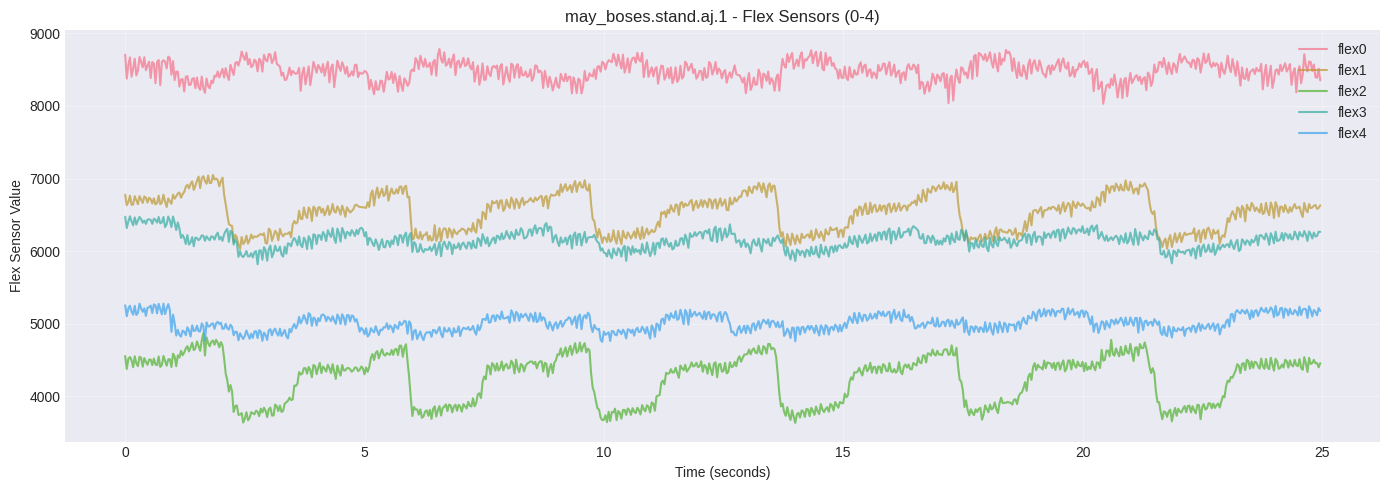

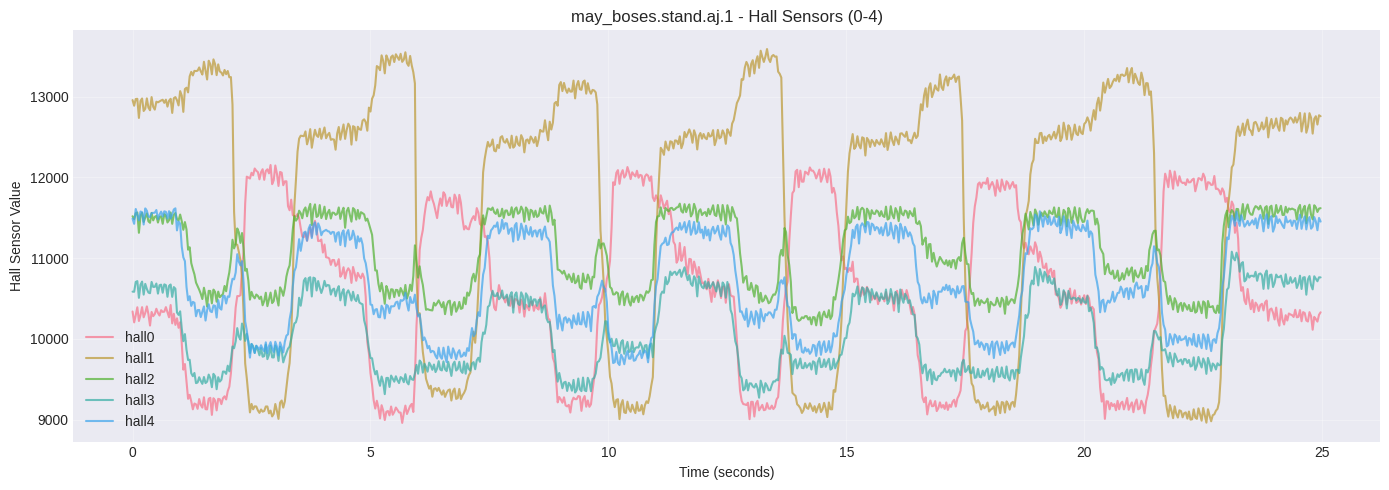

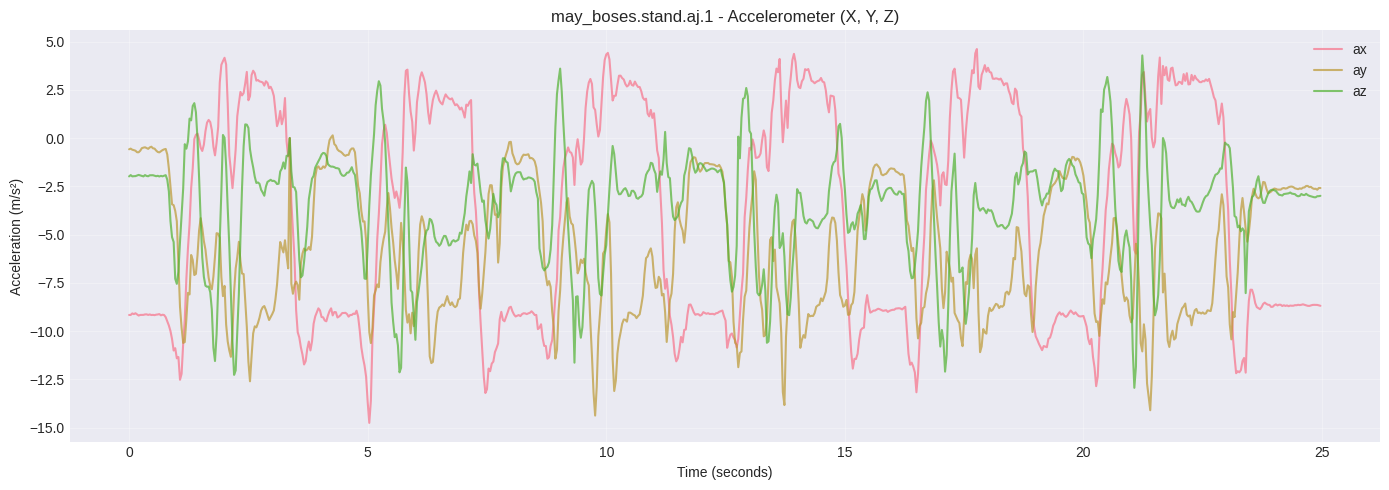

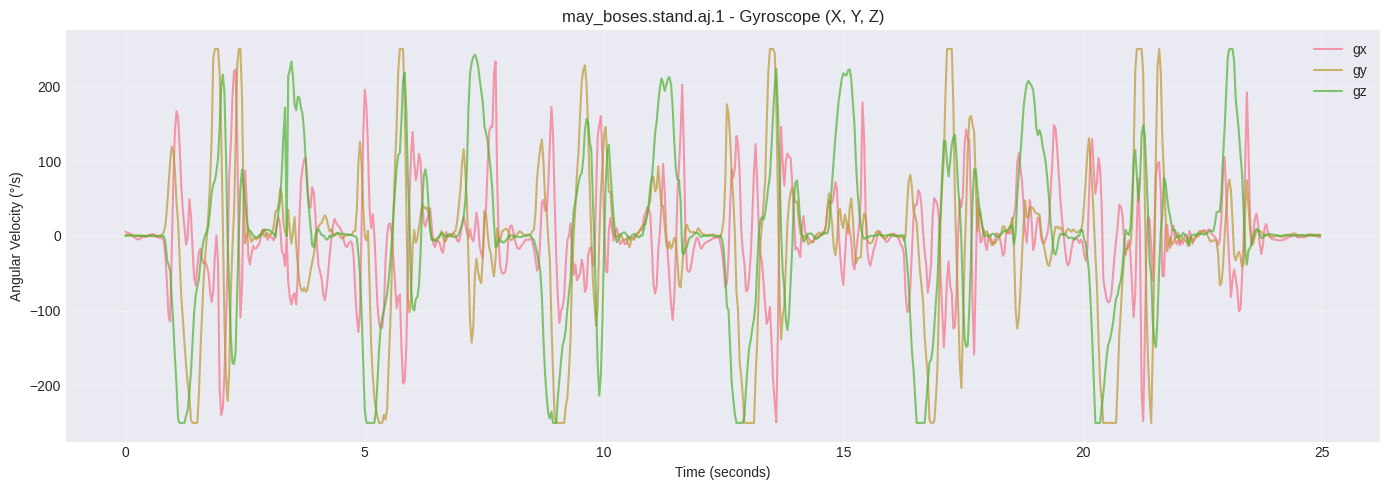

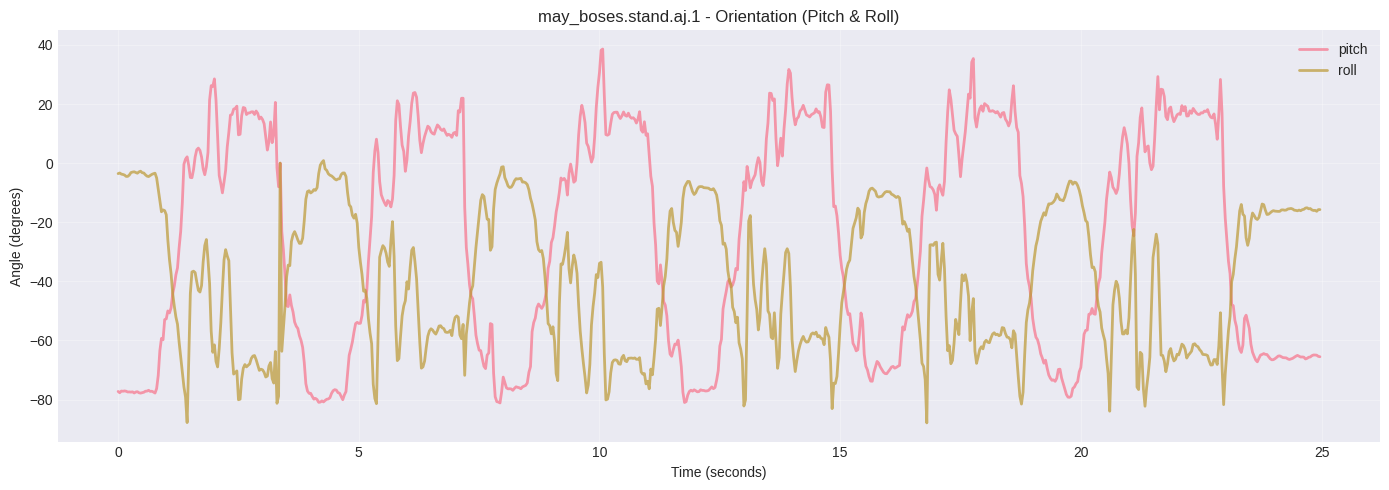


Sensors in may_boses.stand.aj.1:
  ✓ Flex: 5
  ✓ Hall: 5
  ✓ Accelerometer: 3
  ✓ Gyroscope: 3
  ✓ Orientation: 2

Data Quality:
  NaN values: 0
  All-zero rows: 0
  Data completeness: 100.0%

Dataset: naririnig_ko.sit.aj.2

Samples: 750 (valid: 750)
Duration: 25.0s (0.4m)
Sampling interval: 33.33ms



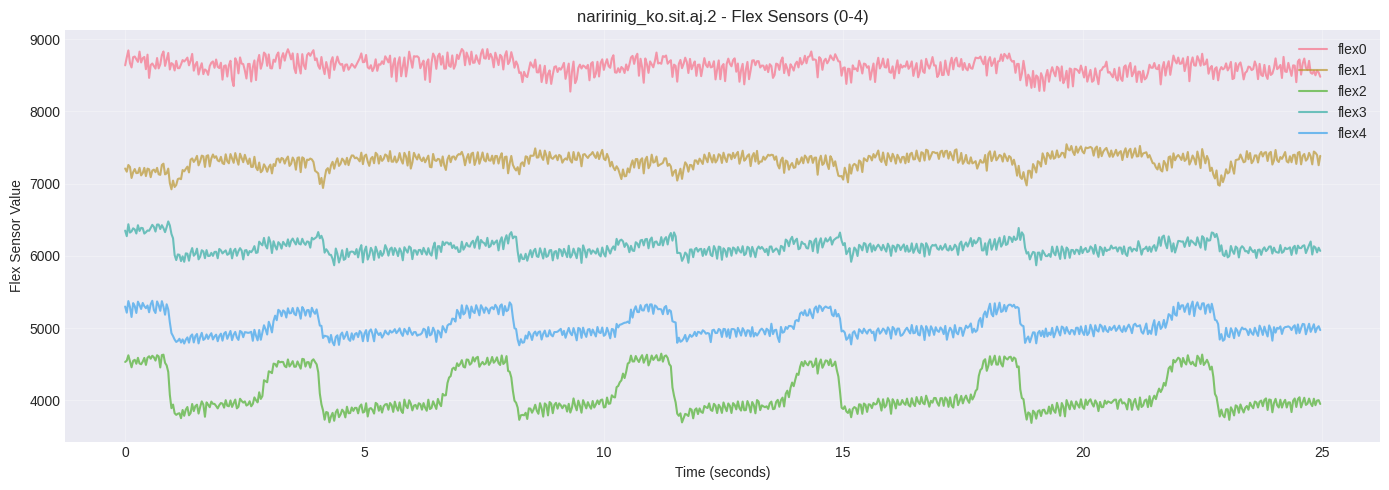

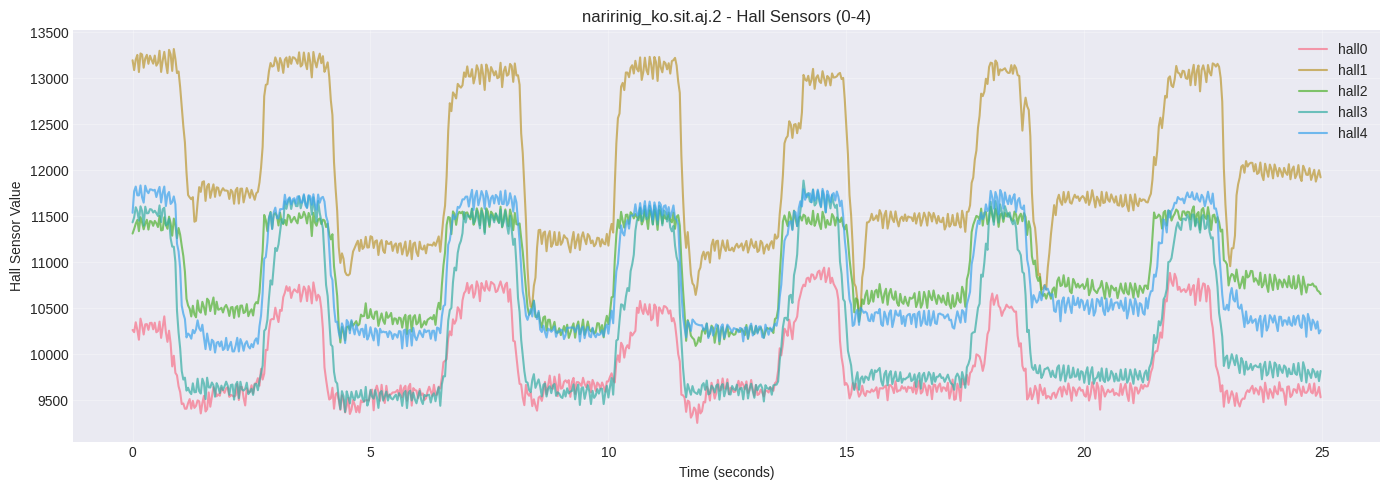

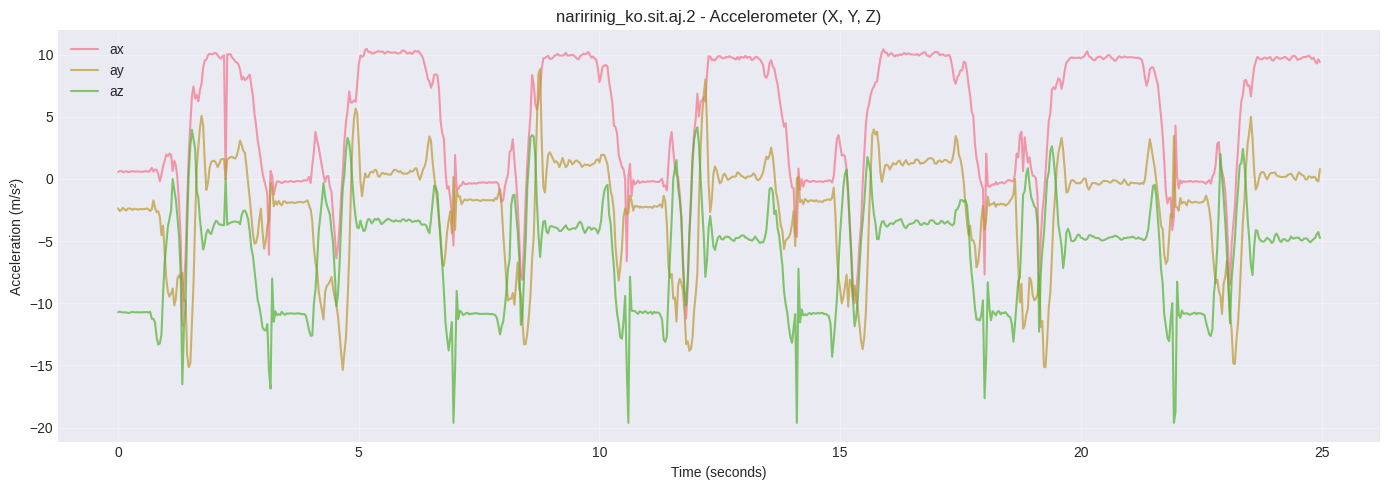

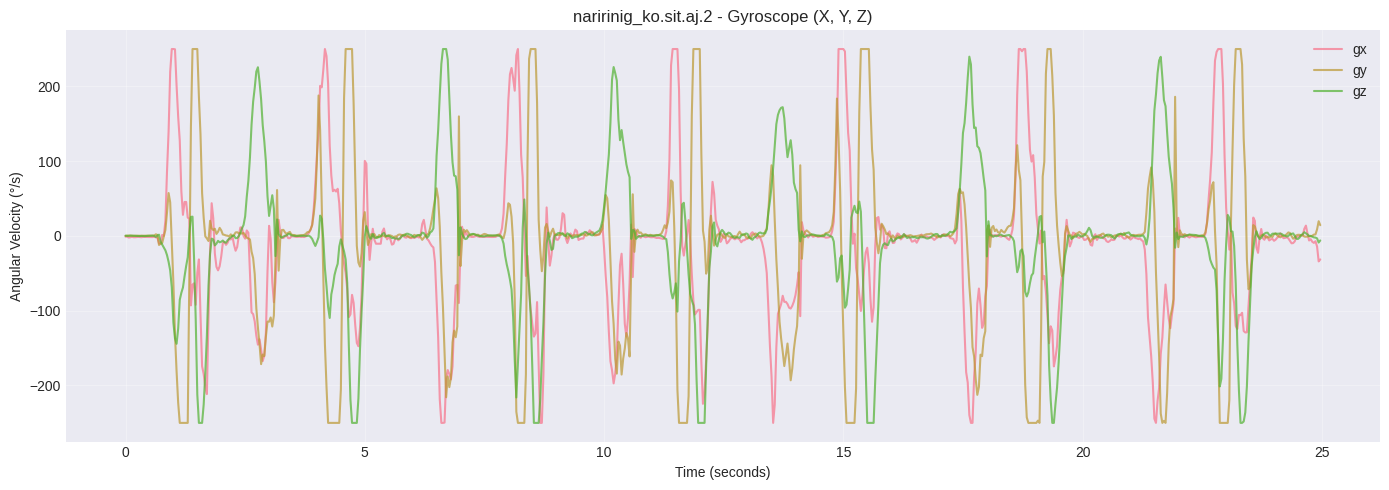

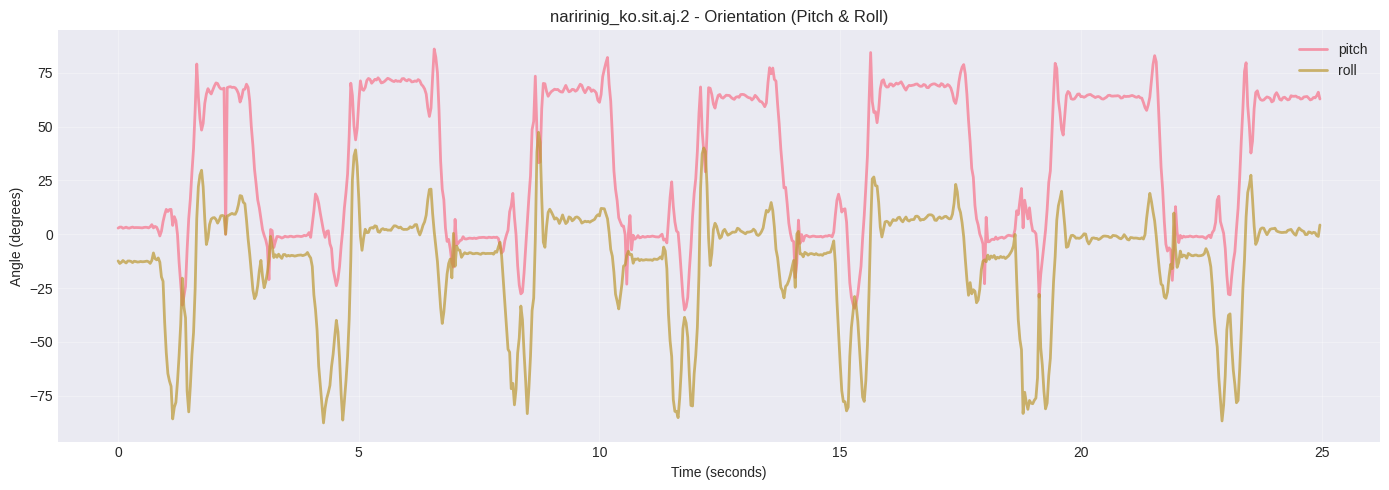


Sensors in naririnig_ko.sit.aj.2:
  ✓ Flex: 5
  ✓ Hall: 5
  ✓ Accelerometer: 3
  ✓ Gyroscope: 3
  ✓ Orientation: 2

Data Quality:
  NaN values: 0
  All-zero rows: 0
  Data completeness: 100.0%

Dataset: random.ciello

Samples: 1,800 (valid: 1,800)
Duration: 60.0s (1.0m)
Sampling interval: 33.33ms



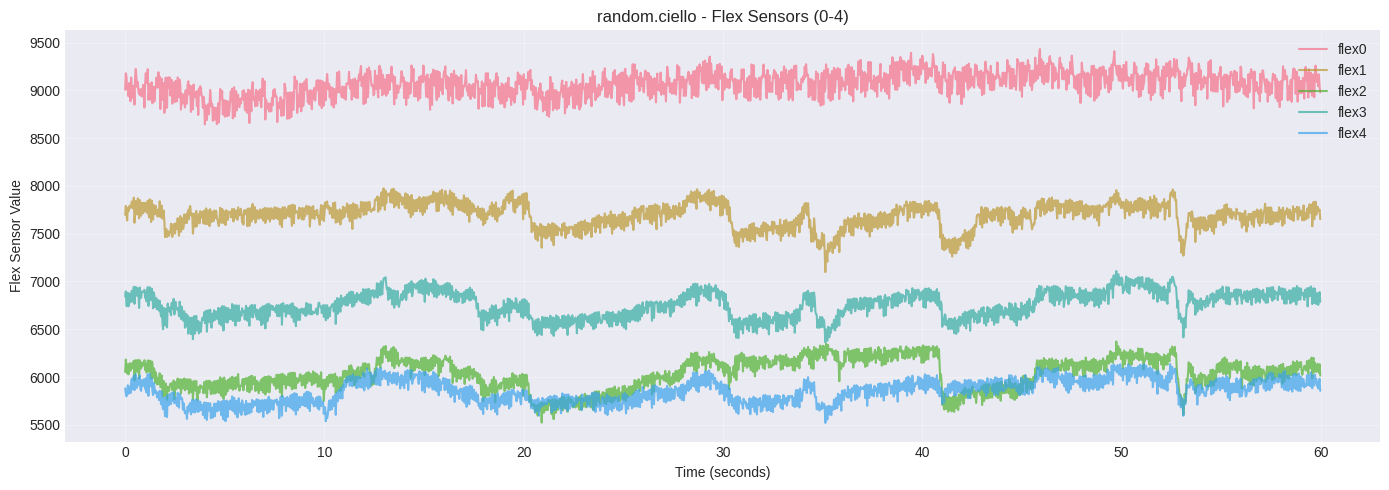

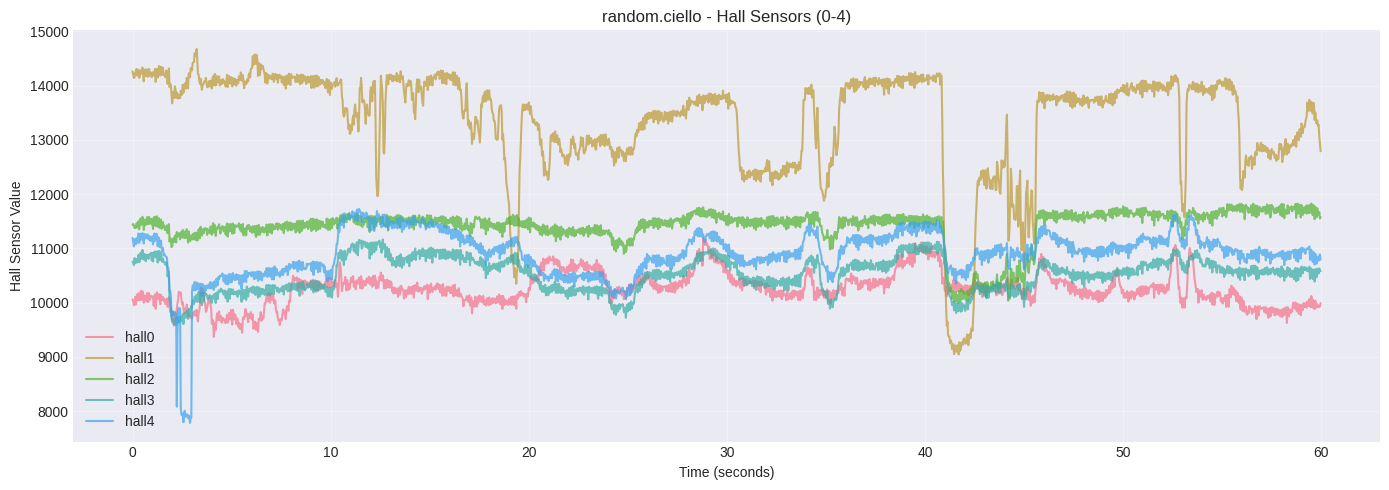

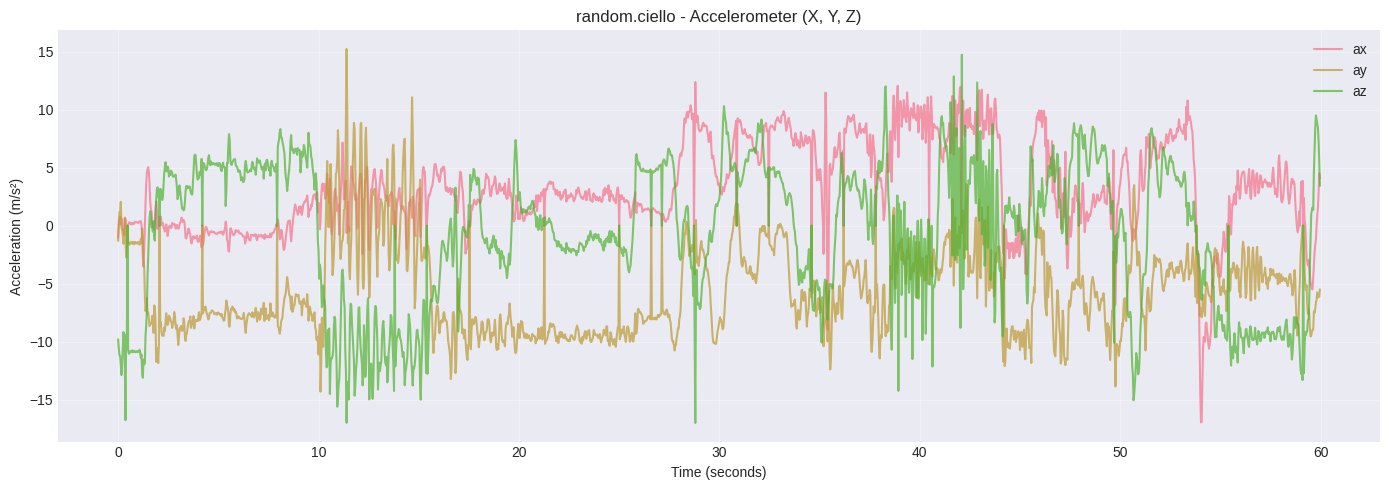

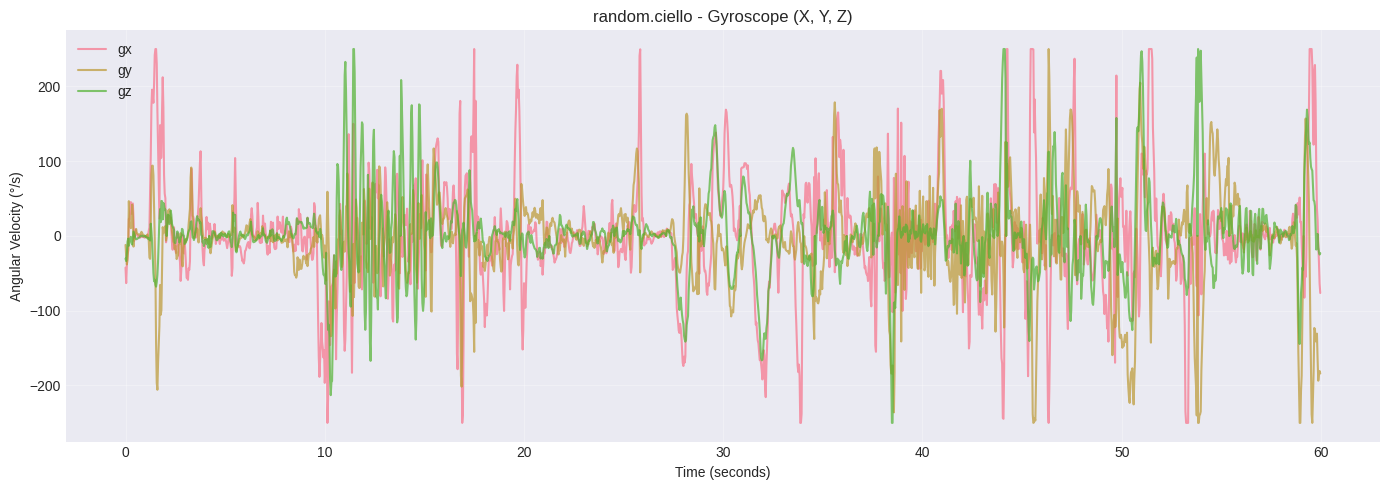

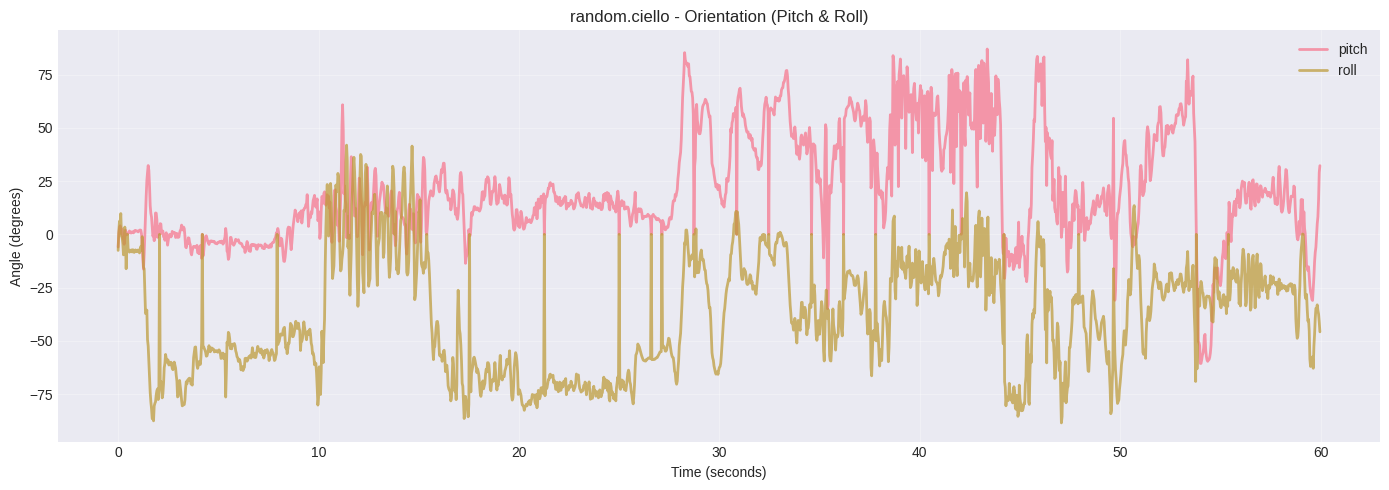


Sensors in random.ciello:
  ✓ Flex: 5
  ✓ Hall: 5
  ✓ Accelerometer: 3
  ✓ Gyroscope: 3
  ✓ Orientation: 2

Data Quality:
  NaN values: 0
  All-zero rows: 0
  Data completeness: 100.0%

✓ Visualizations complete for all 3 dataset(s)


In [68]:
# 17. Create Comprehensive Visualizations for Each Dataset
if len(json_datasets) > 0:
    print("Generating visualizations for each dataset...\n")
    
    # Create visualizations for each dataset
    for dataset_name, dataset_data in json_datasets.items():
        print(f"\n{'='*80}")
        print(f"Dataset: {dataset_name}")
        print(f"{'='*80}\n")
        
        # Extract data
        payload_data = dataset_data['payload']
        sensors = [s['name'] for s in payload_data['sensors']]
        values = payload_data['values']
        interval_ms_data = payload_data['interval_ms']
        
        # Create dataframe
        df_dataset = pd.DataFrame(values, columns=sensors)
        
        # Validate and clean
        for col in sensors:
            df_dataset[col] = pd.to_numeric(df_dataset[col], errors='coerce')
        
        # Remove all-zero rows for visualization
        zero_rows_data = (df_dataset == 0).all(axis=1)
        df_dataset_clean = df_dataset[~zero_rows_data].copy()
        
        # Create time axis
        delta_t_data = interval_ms_data / 1000
        time_seconds_data = np.arange(len(df_dataset_clean)) * delta_t_data
        
        print(f"Samples: {len(df_dataset):,} (valid: {len(df_dataset_clean):,})")
        print(f"Duration: {time_seconds_data[-1]:.1f}s ({time_seconds_data[-1]/60:.1f}m)")
        print(f"Sampling interval: {interval_ms_data:.2f}ms\n")
        
        # Define sensor groups
        flex_sensors_data = ['flex0', 'flex1', 'flex2', 'flex3', 'flex4']
        hall_sensors_data = ['hall0', 'hall1', 'hall2', 'hall3', 'hall4']
        accel_sensors_data = ['ax', 'ay', 'az']
        gyro_sensors_data = ['gx', 'gy', 'gz']
        orient_sensors_data = ['pitch', 'roll']
        
        # Filter to only sensors that exist in this dataset
        flex_sensors_data = [s for s in flex_sensors_data if s in sensors]
        hall_sensors_data = [s for s in hall_sensors_data if s in sensors]
        accel_sensors_data = [s for s in accel_sensors_data if s in sensors]
        gyro_sensors_data = [s for s in gyro_sensors_data if s in sensors]
        orient_sensors_data = [s for s in orient_sensors_data if s in sensors]
        
        # Plot Flex Sensors
        if flex_sensors_data:
            fig, ax = plt.subplots(figsize=(14, 5))
            for sensor in flex_sensors_data:
                ax.plot(time_seconds_data, df_dataset_clean[sensor].values, label=sensor, alpha=0.7, linewidth=1.5)
            ax.set_xlabel('Time (seconds)')
            ax.set_ylabel('Flex Sensor Value')
            ax.set_title(f'{dataset_name} - Flex Sensors (0-4)')
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        # Plot Hall Sensors
        if hall_sensors_data:
            fig, ax = plt.subplots(figsize=(14, 5))
            for sensor in hall_sensors_data:
                ax.plot(time_seconds_data, df_dataset_clean[sensor].values, label=sensor, alpha=0.7, linewidth=1.5)
            ax.set_xlabel('Time (seconds)')
            ax.set_ylabel('Hall Sensor Value')
            ax.set_title(f'{dataset_name} - Hall Sensors (0-4)')
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        # Plot Accelerometer
        if accel_sensors_data:
            fig, ax = plt.subplots(figsize=(14, 5))
            for sensor in accel_sensors_data:
                ax.plot(time_seconds_data, df_dataset_clean[sensor].values, label=sensor, alpha=0.7, linewidth=1.5)
            ax.set_xlabel('Time (seconds)')
            ax.set_ylabel('Acceleration (m/s²)')
            ax.set_title(f'{dataset_name} - Accelerometer (X, Y, Z)')
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        # Plot Gyroscope
        if gyro_sensors_data:
            fig, ax = plt.subplots(figsize=(14, 5))
            for sensor in gyro_sensors_data:
                ax.plot(time_seconds_data, df_dataset_clean[sensor].values, label=sensor, alpha=0.7, linewidth=1.5)
            ax.set_xlabel('Time (seconds)')
            ax.set_ylabel('Angular Velocity (°/s)')
            ax.set_title(f'{dataset_name} - Gyroscope (X, Y, Z)')
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        # Plot Orientation
        if orient_sensors_data:
            fig, ax = plt.subplots(figsize=(14, 5))
            for sensor in orient_sensors_data:
                ax.plot(time_seconds_data, df_dataset_clean[sensor].values, label=sensor, alpha=0.7, linewidth=2)
            ax.set_xlabel('Time (seconds)')
            ax.set_ylabel('Angle (degrees)')
            ax.set_title(f'{dataset_name} - Orientation (Pitch & Roll)')
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        # Show statistics
        print(f"\nSensors in {dataset_name}:")
        if flex_sensors_data:
            print(f"  ✓ Flex: {len(flex_sensors_data)}")
        if hall_sensors_data:
            print(f"  ✓ Hall: {len(hall_sensors_data)}")
        if accel_sensors_data:
            print(f"  ✓ Accelerometer: {len(accel_sensors_data)}")
        if gyro_sensors_data:
            print(f"  ✓ Gyroscope: {len(gyro_sensors_data)}")
        if orient_sensors_data:
            print(f"  ✓ Orientation: {len(orient_sensors_data)}")
        
        # Show data quality
        print(f"\nData Quality:")
        nan_count_data = df_dataset[sensors].isna().sum().sum()
        print(f"  NaN values: {nan_count_data}")
        print(f"  All-zero rows: {zero_rows_data.sum()}")
        print(f"  Data completeness: {100 * (1 - nan_count_data/(len(df_dataset)*len(sensors))):.1f}%")
    
    print(f"\n{'='*80}")
    print(f"✓ Visualizations complete for all {len(json_datasets)} dataset(s)")
    print(f"{'='*80}")
    
else:
    print("No datasets loaded. Please run cells 13-14 first.")

In [69]:
# 18. Generate Comprehensive Multi-File Report
report_output_dir = pathlib.Path('./output')
report_output_dir.mkdir(exist_ok=True)

# Generate comprehensive report
report_file = report_output_dir / 'multi_file_analysis_report.txt'

with open(report_file, 'w') as f:
    f.write("="*100 + "\n")
    f.write("EDGEIMPULSE MULTI-FILE ANALYSIS REPORT\n")
    f.write("="*100 + "\n\n")
    
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Analysis includes {len(json_datasets)} JSON file(s)\n\n")
    
    # Summary table
    f.write("FILE INVENTORY\n")
    f.write("-"*100 + "\n")
    f.write(f"{'File':<30} {'Device':<20} {'Samples':<12} {'Duration (s)':<15} {'Sensors':<10}\n")
    f.write("-"*100 + "\n")
    
    for file_name, meta in json_metadata.items():
        f.write(f"{file_name:<30} {meta['device_name']:<20} {meta['num_samples']:<12} {meta['duration_sec']:<15.2f} {meta['num_sensors']:<10}\n")
    
    f.write("\n")
    f.write("METADATA COMPARISON\n")
    f.write("-"*100 + "\n")
    
    if len(json_metadata) > 1:
        durations = [m['duration_sec'] for m in json_metadata.values()]
        samples = [m['num_samples'] for m in json_metadata.values()]
        
        f.write(f"Total files: {len(json_metadata)}\n")
        f.write(f"Total samples across all files: {sum(samples)}\n")
        f.write(f"Total duration: {sum(durations):.1f} seconds ({sum(durations)/60:.1f} minutes)\n")
        f.write(f"Average duration per file: {np.mean(durations):.1f} seconds\n")
        f.write(f"Average samples per file: {np.mean(samples):.0f}\n\n")
        
    # Sensor configuration details
    f.write("SENSOR CONFIGURATION DETAILS\n")
    f.write("-"*100 + "\n")
    
    for file_name, sensors in sensor_configs.items():
        f.write(f"\n{file_name}:\n")
        f.write(f"  Count: {len(sensors)}\n")
        f.write(f"  Sensors: {', '.join(sensors)}\n")
        
        # Group sensors by type
        flex = [s for s in sensors if 'flex' in s.lower()]
        hall = [s for s in sensors if 'hall' in s.lower()]
        accel = [s for s in sensors if s in ['ax', 'ay', 'az']]
        gyro = [s for s in sensors if s in ['gx', 'gy', 'gz']]
        other = [s for s in sensors if s not in flex + hall + accel + gyro]
        
        if flex:
            f.write(f"    - Flex sensors: {len(flex)} ({', '.join(flex)})\n")
        if hall:
            f.write(f"    - Hall sensors: {len(hall)} ({', '.join(hall)})\n")
        if accel:
            f.write(f"    - Accelerometer: {len(accel)} axes ({', '.join(accel)})\n")
        if gyro:
            f.write(f"    - Gyroscope: {len(gyro)} axes ({', '.join(gyro)})\n")
        if other:
            f.write(f"    - Other: {', '.join(other)}\n")
    
    # Data quality summary
    f.write("\n\nDATA QUALITY ASSESSMENT\n")
    f.write("-"*100 + "\n")
    
    for file_name, data in json_datasets.items():
        payload = data['payload']
        values = payload['values']
        sensors = [s['name'] for s in payload['sensors']]
        
        df_temp = pd.DataFrame(values, columns=sensors)
        
        # Count anomalies
        for col in sensors:
            df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
        
        nan_count = df_temp.isna().sum().sum()
        zero_rows = (df_temp == 0).all(axis=1).sum()
        
        f.write(f"\n{file_name}:\n")
        f.write(f"  NaN values: {nan_count}\n")
        f.write(f"  All-zero rows: {zero_rows}\n")
        f.write(f"  Data completeness: {100 * (1 - nan_count/(len(df_temp)*len(sensors))):.1f}%\n")
    
    f.write("\n" + "="*100 + "\n")
    f.write("END OF REPORT\n")
    f.write("="*100 + "\n")

print(f"✓ Report generated: {report_file}")

# Also save metadata comparison as CSV
metadata_df = pd.DataFrame(json_metadata).T
metadata_csv = report_output_dir / 'multi_file_metadata.csv'
metadata_df.to_csv(metadata_csv)
print(f"✓ Metadata CSV saved: {metadata_csv}")

print(f"\n{'='*80}")
print(f"Multi-file analysis complete!")
print(f"Output files saved to: {report_output_dir}")
print(f"{'='*80}")

✓ Report generated: output/multi_file_analysis_report.txt
✓ Metadata CSV saved: output/multi_file_metadata.csv

Multi-file analysis complete!
Output files saved to: output


## Multi-File Analysis Summary

This section has completed a comprehensive analysis of all JSON files found in your data directories:

### What Was Analyzed:
- ✓ Discovered all EdgeImpulse JSON exports
- ✓ Extracted metadata from each file
- ✓ Compared sensor configurations
- ✓ Analyzed data characteristics and quality
- ✓ Generated comparative visualizations
- ✓ Created detailed reports

### Key Outputs:
1. **multi_file_metadata.csv** - Metadata comparison table
2. **multi_file_analysis_report.txt** - Comprehensive analysis report
3. **Comparative charts** - Visual comparisons (if multiple files)

### Analysis Includes:
- Dataset statistics (samples, duration, intervals)
- Sensor configuration analysis and comparison
- Data quality metrics (NaNs, anomalies)
- Device consistency checks
- Temporal characteristics

All results are saved in the `output/` folder for further processing and model training.

# EdgeImpulse JSON Data Visualization
This notebook loads, validates, cleans, and visualizes time-series sensor data exported from EdgeImpulse.